# Machine Learning Models for Severity Classification

## Logistic regreassion

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
df = pd.read_csv("../data/clean_airline_reviews.csv")

df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,full_review_text,clean_review_text,processed_text,final_text
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,...,4.0,4.0,NaN,NaN,3.0,yes,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni to moheli turned ...,pretty decent airline moroni moheli turned pre...,pretty decent airline moroni moheli turned pre...
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,"""Not a good airline"" Moroni to Anjouan. It is...",not a good airline moroni to anjouan it is a v...,good airline moroni anjouan small airline tick...,good airline moroni anjouan small airline tick...
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,"""flight was fortunately short"" Anjouan to Dz...",flight was fortunately short anjouan to dzaoud...,flight fortunately short anjouan dzaoudzi smal...,flight fortunately short anjouan dzaoudzi smal...
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,...,NaN,1.0,NaN,NaN,1.0,no,"""I will never fly again with Adria"" Please d...",i will never fly again with adria please do a ...,never fly adria please favor fly adria route m...,never fly adria please favor fly adria route m...
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,1.0,1.0,no,"""it ruined our last days of holidays"" Do not ...",it ruined our last days of holidays do not boo...,ruined last days holidays book flight airline ...,ruined last day holiday book flight airline fr...


In [5]:
df["Overall_Rating"] = pd.to_numeric(df["Overall_Rating"], errors="coerce")

In [6]:
df = df.dropna(subset=["Overall_Rating"])

df.shape

(22329, 24)

In [7]:
def severity_label(rating):
    if rating <= 2:
        return "Critical"
    elif rating <= 4:
        return "High"
    elif rating <= 6:
        return "Medium"
    else:
        return "Low"

In [8]:
df["severity_label"] = df["Overall_Rating"].apply(severity_label)

df["severity_label"].value_counts()

severity_label
Critical    13891
Low          4718
High         2215
Medium       1505
Name: count, dtype: int64

In [9]:
label_encoder = LabelEncoder()

df["severity_id"] = label_encoder.fit_transform(df["severity_label"])

df[["severity_label", "severity_id"]].head()

,severity_label,severity_id
0,Low,2
1,Critical,0
2,Critical,0
3,Critical,0
4,Critical,0


In [10]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [11]:
X = vectorizer.fit_transform(df["final_text"])
y = df["severity_id"]

X.shape

(22329, 10000)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.69      0.77      2773
           1       0.23      0.34      0.27       475
           2       0.61      0.76      0.68       948
           3       0.24      0.38      0.30       270

    accuracy                           0.65      4466
   macro avg       0.49      0.54      0.50      4466
weighted avg       0.72      0.65      0.67      4466

[[1905  442  321  105]
 [ 166  161   53   95]
 [  54   56  720  118]
 [  38   53   77  102]]


In [13]:
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

0: Critical
1: High
2: Low
3: Medium


## Naive Bayes

In [14]:
from sklearn.naive_bayes import MultinomialNB

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [16]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      2773
           1       0.50      0.00      0.01       475
           2       0.55      0.84      0.66       948
           3       0.00      0.00      0.00       270

    accuracy                           0.72      4466
   macro avg       0.46      0.43      0.38      4466
weighted avg       0.67      0.72      0.66      4466



d:\Data science - Projects\airline-complaint-severity-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data science - Projects\airline-complaint-severity-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data science - Projects\airline-complaint-severity-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

In [17]:
from sklearn.svm import LinearSVC

In [18]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [19]:
y_pred_svm = svm_model.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83      2773
           1       0.28      0.11      0.16       475
           2       0.62      0.68      0.65       948
           3       0.22      0.10      0.14       270

    accuracy                           0.71      4466
   macro avg       0.47      0.44      0.44      4466
weighted avg       0.66      0.71      0.68      4466



## Confusion Matrix

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_test, y_pred, model_name):
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

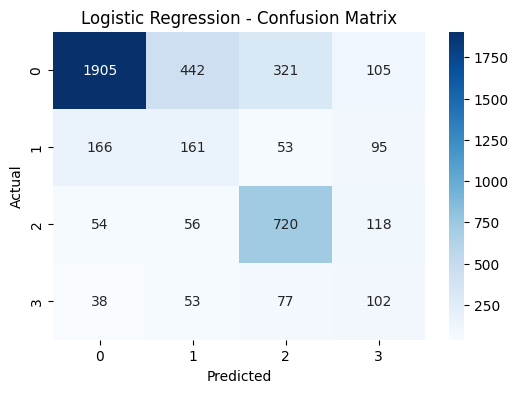

In [22]:
plot_confusion_matrix(y_test, y_pred, "Logistic Regression")

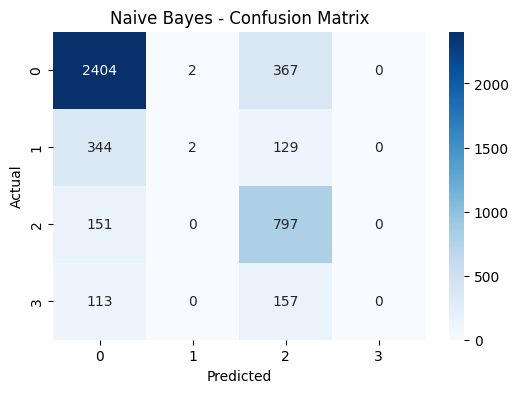

In [23]:
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")

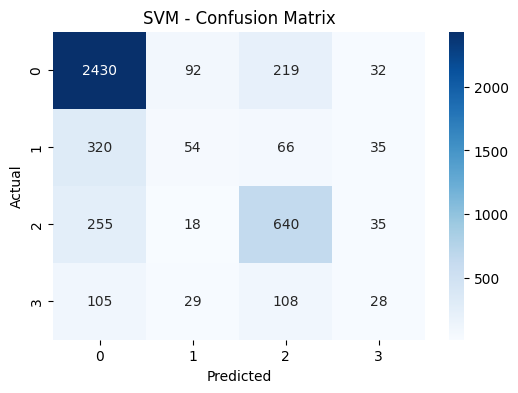

In [24]:
plot_confusion_matrix(y_test, y_pred_svm, "SVM")

## Model Comparison

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [26]:
def get_metrics(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1 Score": f1_score(y_test, y_pred, average='macro')
    }

In [27]:
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **get_metrics(y_test, y_pred)
})

# Naive Bayes
results.append({
    "Model": "Naive Bayes",
    **get_metrics(y_test, y_pred_nb)
})

# SVM
results.append({
    "Model": "SVM",
    **get_metrics(y_test, y_pred_svm)
})

results_df = pd.DataFrame(results)

d:\Data science - Projects\airline-complaint-severity-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
results_df
results_df.to_csv("../models/model_results.csv", index=False)

## Model Comparison Conclusion

Among the three models tested (Logistic Regression, Naive Bayes, and SVM), SVM performed the best overall.

Although Logistic Regression and Naive Bayes achieved slightly higher accuracy, they showed poor performance in minority classes due to dataset imbalance.

SVM achieved the highest F1-score and better recall across classes, making it the most balanced and reliable model for severity classification.

Therefore, SVM is selected as the best performing traditional machine learning model for this task.